In [15]:
import sys
sys.path.insert(0, '../Week-5-6-7-8')

import json
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR

from helpers.modeling import prepare_data, identify_column_types, create_preprocessor
from uncertainty import run_conformal, calibration_table

with open('../Week-5-6-7-8/results.json', 'r') as f:
    results = json.load(f)

df = pd.read_csv("../Datasets/processed/UHPC_dataset/semantic_recoding_features_50_with_publications.csv")

In [16]:
df_shared_pub = df.drop(columns='paper_reference')
target_col = 'cs_28d'

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df_shared_pub, target_col)

pub_test = df.loc[X_test.index, 'paper_reference']  
pub_val  = df.loc[X_val.index,  'paper_reference']  

print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

X = df_shared_pub.drop(columns=[target_col])
numerical_cols, one_hot_columns, k_fold_columns = identify_column_types(X)

preprocessor = create_preprocessor(numerical_cols, one_hot_columns, k_fold_columns,
                                   handle_unknown='ignore')

print(f"After encoding Training Set Shape: {preprocessor.fit_transform(X_train, y_train).shape}")
print(f"After encoding Validation Set Shape: {preprocessor.transform(X_val).shape}")
print(f"After encoding Test Set Shape: {preprocessor.transform(X_test).shape}")



Train set size: 1451
Validation set size: 311
Test set size: 311
After encoding Training Set Shape: (1451, 60)
After encoding Validation Set Shape: (311, 60)
After encoding Test Set Shape: (311, 60)


In [17]:
processed = preprocessor.transform(X_train)
df1 = pd.DataFrame(processed)
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,-0.753431,0.071215,-0.965015,-0.820468,0.451098,-1.435367,-0.420784,-0.231084,-0.526882,-0.2788,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.548519,0.071215,-0.670998,0.708760,0.574214,-0.003464,-0.420784,-0.231084,-0.526882,-0.2788,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.753431,0.707753,0.036451,-0.820468,0.687421,0.089832,0.209871,-0.231084,-0.526882,-0.2788,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.548519,0.071215,1.077673,0.708760,-1.878287,-0.826023,1.287198,-0.231084,-0.526882,-0.2788,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.103347,0.071215,0.948714,0.708760,0.476114,0.472755,-0.420784,-0.231084,-0.526882,-0.2788,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [18]:
pipeline_knn, train_knn, test_knn, q_knn, intervals_knn, calibration_knn = run_conformal(
    KNeighborsRegressor, 'knn', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_knn}")
print(f"Test:  {test_knn}")
print(f"Conformal q (90%): {q_knn:.2f}")
calibration_knn

Train: {'RMSE': np.float64(5.444646469074675), 'MAE': 3.1822768891900335, 'R2': 0.9777523051553427, 'Correlation': np.float64(0.988987721553185), 'Mean_Residual': np.float64(-0.18443397735292905), 'N': 1451}
Test:  {'RMSE': np.float64(15.351922436927747), 'MAE': 10.895631319595534, 'R2': 0.7984932269393928, 'Correlation': np.float64(0.8942422545046707), 'Mean_Residual': np.float64(1.0934947684096805), 'N': 311}
Conformal q (90%): 29.38


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,2,119.250,126.435089,1.0,58.751432,7.185089,2.638109
1,Ref-10-Research,4,152.125,133.393659,0.5,58.751432,23.677780,4.292566
2,Ref-100-Research,1,105.600,112.947663,1.0,58.751432,7.347663,2.968594
3,Ref-101-Research,2,140.550,151.002046,1.0,58.751432,10.452046,1.150344
4,Ref-102-Research,2,158.000,162.117853,1.0,58.751432,4.117853,3.487686
...,...,...,...,...,...,...,...,...
100,Ref-92-Research,1,149.000,177.412602,1.0,58.751432,28.412602,2.197006
101,Ref-93-Research,1,156.000,138.974997,1.0,58.751432,17.025003,2.718423
102,Ref-94-Research,1,176.000,165.622601,1.0,58.751432,10.377399,5.087427
103,Ref-96-Research,1,126.000,143.902068,1.0,58.751432,17.902068,4.650974


In [19]:
pipeline_svr, train_svr, test_svr, q_svr, intervals_svr, calibration_svr = run_conformal(
    SVR, 'svr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_svr}")
print(f"Test:  {test_svr}")
print(f"Conformal q (90%): {q_svr:.2f}")
calibration_svr

Train: {'RMSE': np.float64(7.773862777322706), 'MAE': 4.87412971178084, 'R2': 0.9546456038996406, 'Correlation': np.float64(0.9771854370651195), 'Mean_Residual': np.float64(-0.11791066009085462), 'N': 1451}
Test:  {'RMSE': np.float64(13.215642609719916), 'MAE': 9.276301631382413, 'R2': 0.850672194009974, 'Correlation': np.float64(0.9229123072993365), 'Mean_Residual': np.float64(0.4863265998516123), 'N': 311}
Conformal q (90%): 25.07


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,2,119.250,124.785187,1.0,50.134696,5.535187,1.770619
1,Ref-10-Research,4,152.125,143.891915,1.0,50.134696,8.233085,2.442695
2,Ref-100-Research,1,105.600,112.847908,1.0,50.134696,7.247908,2.016936
3,Ref-101-Research,2,140.550,145.489488,1.0,50.134696,4.939488,0.676201
4,Ref-102-Research,2,158.000,162.732410,1.0,50.134696,7.065009,1.830184
...,...,...,...,...,...,...,...,...
100,Ref-92-Research,1,149.000,154.461931,1.0,50.134696,5.461931,1.863120
101,Ref-93-Research,1,156.000,138.783996,1.0,50.134696,17.216004,1.938970
102,Ref-94-Research,1,176.000,169.864713,1.0,50.134696,6.135287,2.572940
103,Ref-96-Research,1,126.000,136.914194,1.0,50.134696,10.914194,2.791894


In [20]:
pipeline_nusvr, train_nusvr, test_nusvr, q_nusvr, intervals_nusvr, calibration_nusvr = run_conformal(
    NuSVR, 'nusvr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_nusvr}")
print(f"Test:  {test_nusvr}")
print(f"Conformal q (90%): {q_nusvr:.2f}")
calibration_nusvr

Train: {'RMSE': np.float64(7.436144504572517), 'MAE': 4.850675973997704, 'R2': 0.9585006504753844, 'Correlation': np.float64(0.9790879076040112), 'Mean_Residual': np.float64(-0.2031257109659451), 'N': 1451}
Test:  {'RMSE': np.float64(13.200549778299774), 'MAE': 9.216213249002015, 'R2': 0.8510130767823418, 'Correlation': np.float64(0.923827559331842), 'Mean_Residual': np.float64(0.4622760252350381), 'N': 311}
Conformal q (90%): 24.19


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,2,119.250,122.605017,1.0,48.376675,3.355017,1.769671
1,Ref-10-Research,4,152.125,143.450220,1.0,48.376675,8.674780,2.447841
2,Ref-100-Research,1,105.600,111.679417,1.0,48.376675,6.079417,2.016054
3,Ref-101-Research,2,140.550,145.120665,1.0,48.376675,4.570665,0.676201
4,Ref-102-Research,2,158.000,162.819244,1.0,48.376675,6.600552,1.830822
...,...,...,...,...,...,...,...,...
100,Ref-92-Research,1,149.000,143.667611,1.0,48.376675,5.332389,1.863498
101,Ref-93-Research,1,156.000,139.565816,1.0,48.376675,16.434184,1.939186
102,Ref-94-Research,1,176.000,170.124668,1.0,48.376675,5.875332,2.570508
103,Ref-96-Research,1,126.000,137.371971,1.0,48.376675,11.371971,2.791988


In [23]:
poor_coverage_threshold = 0.9

poor_coverage = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
])
poor_coverage = (
    poor_coverage[poor_coverage['coverage'] < poor_coverage_threshold]
    .sort_values('coverage')
    [['model', 'publication', 'n_rows', 'coverage', 'interval_width', 'mean_residual', 'mean_distance']]
    .reset_index(drop=True)
)

print(f"Publications below {poor_coverage_threshold:.0%} coverage: {poor_coverage['publication'].nunique()} unique, {len(poor_coverage)} model-publication pairs")
poor_coverage

Publications below 90% coverage: 24 unique, 49 model-publication pairs


,model,publication,n_rows,coverage,interval_width,mean_residual,mean_distance
0,knn,Ref-104-Research,1,0.000000,58.751432,44.913694,2.759159
1,knn,Ref-55-Research,1,0.000000,58.751432,50.575919,0.574476
2,knn,Ref-40-Research,1,0.000000,58.751432,59.643319,7.634588
3,knn,Ref-23-Research,1,0.000000,58.751432,40.033186,0.492227
4,knn,Ref-6-Research,1,0.000000,58.751432,40.992026,4.371785
5,svr,Ref-23-Research,1,0.000000,50.134696,47.481933,0.329534
6,svr,Ref-55-Research,1,0.000000,50.134696,48.275506,0.304228
7,nusvr,Ref-23-Research,1,0.000000,48.376675,48.851117,0.329534
8,nusvr,Ref-28-Research,1,0.000000,48.376675,27.006979,1.331096
9,nusvr,Ref-36-Research,2,0.000000,48.376675,33.786388,0.645838


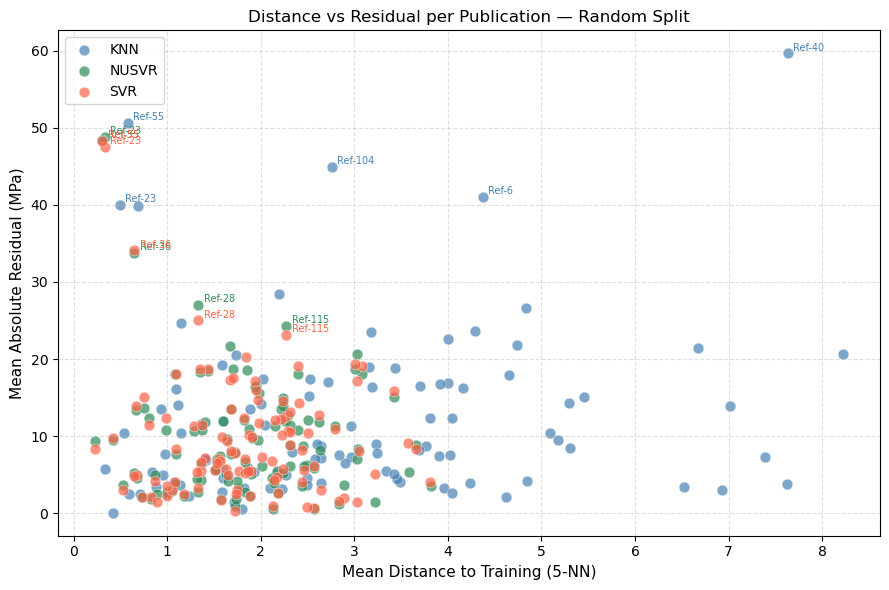

In [24]:
import matplotlib.pyplot as plt

all_cal = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
], ignore_index=True)

colors = {'knn': 'steelblue', 'svr': 'tomato', 'nusvr': 'seagreen'}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, grp in all_cal.groupby('model'):
    ax.scatter(grp['mean_distance'], grp['mean_residual'],
               label=model_name.upper(), color=colors[model_name],
               alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

for model_name, grp in all_cal.groupby('model'):
    for _, row in grp.nlargest(5, 'mean_residual').iterrows():
        ax.annotate(row['publication'].replace('-Research', '').replace('-data', ''),
                    xy=(row['mean_distance'], row['mean_residual']),
                    fontsize=7, color=colors[model_name],
                    xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Mean Distance to Training (5-NN)', fontsize=11)
ax.set_ylabel('Mean Absolute Residual (MPa)', fontsize=11)
ax.set_title('Distance vs Residual per Publication — Random Split', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()